# Social Meaning in Large Language Models

This notebook reproduces the empirical analysis from:

> Mühlenbernd, R. (2026). Social Meaning in Large Language Models: Structure, Magnitude, and Pragmatic Prompting. *Proceedings of CMCL 2026*. arXiv: https://arxiv.org/abs/2604.02512

The human benchmark data originates from:

> Solt, S., Mühlenbernd, R., & Burbelko, M. (2025). Social meaning and pragmatic reasoning: The case of (im)precision. *Proceedings of ELM 3*, 371–382. OSF: https://doi.org/10.17605/OSF.IO/M4RHN

---

## What this notebook covers

Two related questions motivate this work:

1. **Quantitative calibration:** Do LLMs approximate human social meaning not only *qualitatively* (right direction) but also *quantitatively* (right magnitude)?
2. **Pragmatic prompting:** Can prompting strategies informed by pragmatic theory improve this approximation?

We evaluate three frontier LLMs (GPT, Claude, Gemini) across four prompting conditions on a case study of numerical (im)precision, using human behavioral data as a quantitative benchmark.

**Notebook structure:**
1. Environment setup
2. Background: experiment and prompting conditions
3. Load data
4. Structural alignment (DAS, ISS)
5. Global pattern similarity (Spearman ρ, CCC, RMSE) — Table 1
6. Magnitude calibration (ESR, CDS) — Table 2 + Figure 1
7. Run your own experiment *(optional — requires API keys)*
8. Citation

---

## 1. Environment Setup

Run the cell below once at the start of each session. It does two things:

1. **Locates the repository.** Works both locally and in Google Colab. If running in Colab, it automatically clones the project files.
2. **Loads required libraries and project helpers.** Imports all Python packages and the analysis functions written for this project.

In [1]:
# ── 1a. Detect environment and locate the repository ─────────────────────────
import os, sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    if not os.path.exists('llm-social-calibration'):
        !git clone https://github.com/muehlenbernd/llm-social-calibration.git
    os.chdir('llm-social-calibration')
    !pip install -q -r requirements.txt
    print('Running in Colab — repository cloned and dependencies installed.')
else:
    # Ensure we are at the repo root regardless of where the notebook is launched from
    repo_root = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
    os.chdir(repo_root)
    print(f'Running locally. Working directory: {os.getcwd()}')

# Make src/ importable
sys.path.insert(0, os.path.abspath('.'))

# ── 1b. Standard library imports ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', None)

# ── 1c. Project helpers ───────────────────────────────────────────────────────
from src.analysis.metrics import (
    ATTRIBUTES, SIGNIFICANT_MAIN_ATTRS, SIGNIFICANT_INTERACTION_ATTRS,
    HUMAN_MAIN_EFFECTS, HUMAN_INTERACTIONS,
    load_human_data, load_llm_data,
    compute_das, compute_iss,
    compute_comprehensive_alignment_metrics,
    compute_esr_main_all, compute_esr_interaction_all,
    compute_CDS_data,
)
from src.analysis.metrics_plotter import (
    prepare_hlc_dataframe,
    plot_hlc_grid,
    plot_esr_heatmap,
)

print('Environment ready.')

Running locally. Working directory: /Users/roland/GitHub/llm-social-calibration
Environment ready.


---

## 2. Background

### 2.1 The human experiment

The human benchmark comes from Experiment 1 of Solt et al. (2025), a matched-guise study with N = 371 participants. Each participant read one of six everyday scenarios in which a speaker answered a question using either a **precise** or **approximate** numerical expression, in either a **high-precision** or **low-precision** context. For example:

> *Jamie's new bicycle was stolen. The insurance company asks: "How much did the bicycle cost?"*
> - Precise: *"The bicycle cost \$509.55."*
> - Approximate: *"The bicycle cost about \$500."*

Participants rated the speaker on six social attributes using 7-point Likert scales:
- **Competence-related:** competent, knowledgeable, well-prepared
- **Likeability-related:** helpful, likeable
- **Other:** pedantic

The study yielded **10 statistically significant effects** — 5 main effects of form and 5 form × context interactions — which serve as the quantitative benchmark for LLM evaluation.

### 2.2 LLM evaluation design

Three frontier LLMs were evaluated via API: **GPT** (`gpt-4o-mini`), **Claude** (`claude-sonnet-4-20250514`), and **Gemini** (`gemini-2.5-pro`). Each model was prompted with the same scenarios and rating task as human participants, across four prompting conditions:

| Condition | Description |
|-----------|-------------|
| **MIN** | Minimal — mirrors the human experiment instructions verbatim |
| **ALT** | Alternative-Aware — adds a one-shot chain-of-thought exemplar to elicit reasoning over utterance alternatives |
| **KMA** | Knowledge-and-Motives-Aware — instructs the model to consider speaker knowledge states and communicative motives before rating |
| **COM** | Combined — integrates both ALT and KMA extensions |

Each query was run n = 10 times at temperature τ = 1.0. Mean ratings per condition were then compared to the human benchmark.

### 2.3 Evaluation framework

We distinguish two levels of alignment:

- **Structural alignment** — does the model reproduce the *direction* of human effects? (DAS, ISS)
- **Magnitude calibration** — does the model reproduce the *strength* of human effects? (ESR, CDS, CCC, RMSE)

This distinction is the core methodological contribution of the paper.

---

## 3. Load Data

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
HUMAN_PATH = 'data/human_ratings/experiment1.csv'

LLM_PATHS = {
    'MIN': 'data/llm_ratings/results_MIN.json',
    'ALT': 'data/llm_ratings/results_ALT.json',
    'KMA': 'data/llm_ratings/results_KMA.json',
    'COM': 'data/llm_ratings/results_COM.json',
}

# ── Load human data ───────────────────────────────────────────────────────────
human_df = load_human_data(HUMAN_PATH)
print(f'Human data: {len(human_df):,} rows (participant × attribute ratings)')
display(human_df.head(8))

Human data: 2,172 rows (participant × attribute ratings)


,scenario,context,utterance,attribute,rating
0,office,low,precise,competent,5
1,house,low,precise,competent,6
2,conference,low,precise,competent,7
3,cinema,low,precise,competent,6
4,conference,low,precise,competent,6
5,bicycle,low,precise,competent,5
6,cinema,low,precise,competent,6
7,office,low,precise,competent,7


In [3]:
# ── Load LLM data ─────────────────────────────────────────────────────────────
llm_dfs = {label: load_llm_data(path) for label, path in LLM_PATHS.items()}

for label, df in llm_dfs.items():
    models = df['model'].unique()
    print(f'Condition {label}: {len(df):,} rows | models: {", ".join(sorted(models))}')

print()
display(llm_dfs['MIN'].head(6))

Condition MIN: 4,222 rows | models: claude, gemini, gpt
Condition ALT: 4,320 rows | models: claude, gemini, gpt
Condition KMA: 4,316 rows | models: claude, gemini, gpt
Condition COM: 4,306 rows | models: claude, gemini, gpt



,model,scenario,context,utterance,attribute,rating
0,gpt,house,low,precise,pedantic,2.000
1,gpt,house,low,approx,pedantic,2.000
2,gpt,house,high,precise,pedantic,2.000
3,gpt,house,high,approx,pedantic,2.000
4,gpt,cinema,low,precise,pedantic,3.000
5,gpt,cinema,low,approx,pedantic,1.000


In [4]:
# ── Quick overview: human mean ratings by attribute and utterance form ─────────
human_means = (
    human_df
    .groupby(['attribute', 'utterance'])['rating']
    .mean()
    .unstack('utterance')
    .round(2)
)
human_means['precise − approx'] = (human_means['precise'] - human_means['approx']).round(2)
print('Human mean ratings by attribute and utterance form:')
display(human_means)

Human mean ratings by attribute and utterance form:


utterance,approx,precise,precise − approx
attribute,,,
competent,5.150,6.030,0.880
helpful,5.230,6.130,0.900
knowledgeable,5.080,6.050,0.970
likeable,4.900,5.050,0.150
pedantic,3.550,4.430,0.880
well-prepared,4.960,6.230,1.270


---

## 4. Structural Alignment

Before asking *how strongly* models reproduce human social inferences, we ask *whether* they reproduce their direction at all.

Two scores capture this:

- **DAS (Directional Agreement Score):** for each attribute with a significant human main effect, checks whether the sign of (precise − approx) matches the human direction. Ranges from 0 to 1.
- **ISS (Interaction Sensitivity Score):** same logic applied to the form × context interactions — does the model show a larger precise-over-approx advantage in high-precision contexts, as humans do?

A score of 1.0 means perfect directional agreement with the human benchmark.

In [5]:
MODELS = ['gpt', 'claude', 'gemini']
CONDITIONS = list(LLM_PATHS.keys())

das_records = []
iss_records = []

for cond, llm_df in llm_dfs.items():
    for model in MODELS:
        mdf = llm_df[llm_df['model'] == model]
        if len(mdf) == 0:
            continue

        das = compute_das(human_df, mdf)
        iss = compute_iss(human_df, mdf)

        das_vals = [v['agreement'] for v in das.values() if v['agreement'] is not None and not np.isnan(v['agreement'])]
        iss_vals = [v['agreement'] for v in iss.values() if v['agreement'] is not None and not np.isnan(v['agreement'])]

        das_records.append({'Model': model.upper(), 'Condition': cond, 'DAS': np.mean(das_vals)})
        iss_records.append({'Model': model.upper(), 'Condition': cond, 'ISS': np.mean(iss_vals)})

das_df = pd.DataFrame(das_records).pivot(index='Model', columns='Condition', values='DAS')
iss_df = pd.DataFrame(iss_records).pivot(index='Model', columns='Condition', values='ISS')

print('DAS — Directional Agreement Score (main effects):')
display(das_df[CONDITIONS].round(2))
print()
print('ISS — Interaction Sensitivity Score (form × context):')
display(iss_df[CONDITIONS].round(2))

DAS — Directional Agreement Score (main effects):


Condition,MIN,ALT,KMA,COM
Model,,,,
CLAUDE,1.000,1.000,1.000,1.000
GEMINI,1.000,1.000,1.000,1.000
GPT,1.000,1.000,1.000,1.000



ISS — Interaction Sensitivity Score (form × context):


Condition,MIN,ALT,KMA,COM
Model,,,,
CLAUDE,1.000,1.000,1.000,1.000
GEMINI,1.000,1.000,1.000,1.000
GPT,1.000,1.000,1.000,1.000


**Interpretation:** DAS = ISS = 1.0 across all models and conditions confirms the paper's central structural finding: all three LLMs reliably reproduce the *direction* of every significant human social inference, regardless of how they are prompted. This is the "easy part" — the interesting question is whether they also get the magnitudes right.

---

## 5. Global Pattern Similarity

We now move from directional agreement to global alignment between human and model mean ratings across all conditions (attribute × context × utterance form).

Three complementary metrics capture different aspects of alignment:

- **Spearman ρ** — rank-order correspondence: does the model preserve the relative ordering of human ratings across conditions?
- **CCC (Concordance Correlation Coefficient)** — jointly assesses co-variation *and* mean-level agreement; penalizes systematic over- or under-shooting even when rank order is correct
- **RMSE** — average absolute deviation from human ratings on the original 7-point scale

The key insight: if Spearman ρ is high but CCC is substantially lower, the model is preserving rank order while distorting scale — exactly the structure–magnitude dissociation the paper documents.

In [6]:
from scipy.stats import spearmanr

rows = []
for cond, llm_df in llm_dfs.items():
    for model in MODELS:
        mdf = llm_df[llm_df['model'] == model]
        if len(mdf) == 0:
            continue
        metrics = compute_comprehensive_alignment_metrics(human_df, mdf)
        rows.append({
            'Model': model.upper(),
            'Condition': cond,
            'Spearman ρ': metrics['spearman_rho'],
            'CCC': metrics['ccc'],
            'RMSE': metrics['rmse'],
        })

results_df = pd.DataFrame(rows)

# Display as a table matching Table 1 in the paper
table1 = results_df.pivot_table(
    index=['Model', 'Condition'],
    values=['Spearman ρ', 'CCC', 'RMSE']
).round(3)

print('Table 1 — Global pattern similarity metrics:')
display(table1)

Table 1 — Global pattern similarity metrics:


CCC  RMSE  Spearman ρ
Model  Condition                        
CLAUDE ALT       0.754 0.724       0.847
       COM       0.804 0.576       0.946
       KMA       0.739 0.701       0.920
       MIN       0.730 0.766       0.849
GEMINI ALT       0.576 1.422       0.908
       COM       0.659 1.125       0.916
       KMA       0.680 1.066       0.923
       MIN       0.622 1.262       0.910
GPT    ALT       0.812 0.565       0.880
       COM       0.786 0.547       0.832
       KMA       0.754 0.601       0.829
       MIN       0.703 0.811       0.856

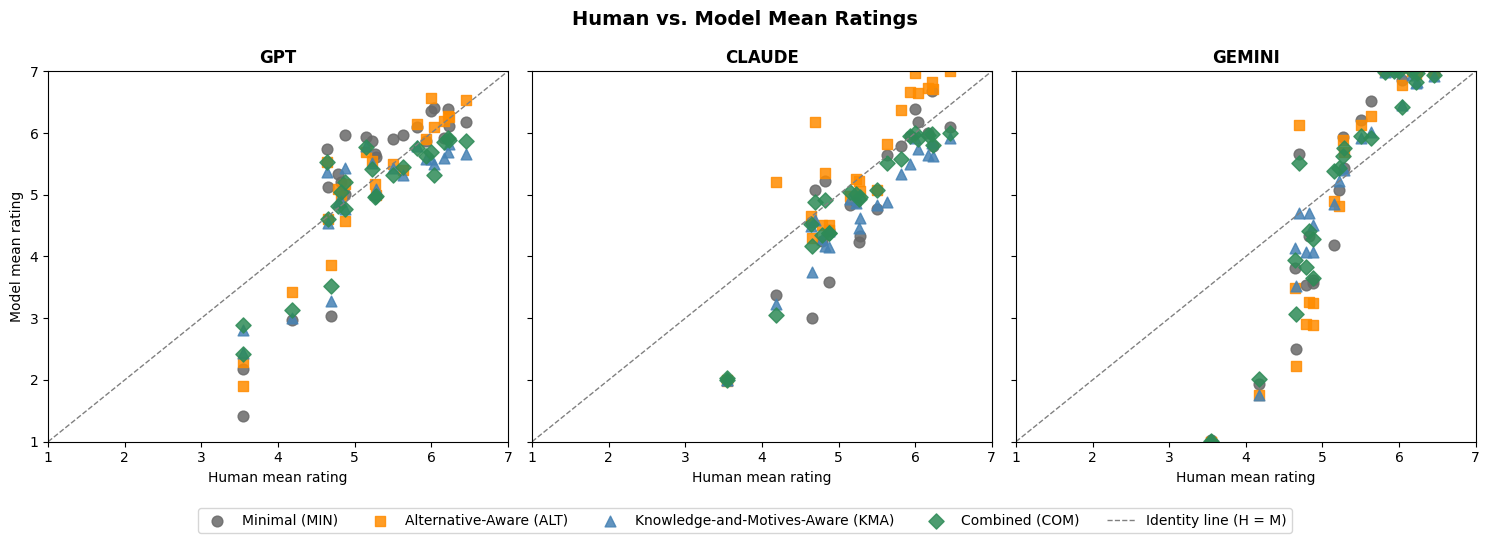

In [7]:
# ── Scatter plot: Human vs. Model mean ratings ────────────────────────────────
# One panel per model, all four conditions overlaid

condition_styles = {
    'MIN': ('o', 'dimgray',  'Minimal (MIN)'),
    'ALT': ('s', 'darkorange', 'Alternative-Aware (ALT)'),
    'KMA': ('^', 'steelblue',  'Knowledge-and-Motives-Aware (KMA)'),
    'COM': ('D', 'seagreen',   'Combined (COM)'),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, model in zip(axes, MODELS):
    human_means_agg = (
        human_df.groupby(['attribute', 'context', 'utterance'])['rating']
        .mean().reset_index().rename(columns={'rating': 'human'})
    )

    for cond, llm_df in llm_dfs.items():
        mdf = llm_df[llm_df['model'] == model]
        llm_means_agg = (
            mdf.groupby(['attribute', 'context', 'utterance'])['rating']
            .mean().reset_index().rename(columns={'rating': 'llm'})
        )
        merged = pd.merge(human_means_agg, llm_means_agg,
                          on=['attribute', 'context', 'utterance'])
        marker, color, label = condition_styles[cond]
        ax.scatter(merged['human'], merged['llm'],
                   marker=marker, color=color, label=label, s=60, alpha=0.85)

    ax.plot([1, 7], [1, 7], '--', color='gray', linewidth=1, label='Identity line (H = M)')
    ax.set_xlim(1, 7); ax.set_ylim(1, 7)
    ax.set_xlabel('Human mean rating')
    ax.set_title(model.upper(), fontweight='bold')

axes[0].set_ylabel('Model mean rating')

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.08))
fig.suptitle('Human vs. Model Mean Ratings', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation:** Points close to the dashed identity line indicate good magnitude calibration. Notice that Gemini's points cluster far above the line — it consistently overestimates the strength of social inferences. GPT sits closest to the diagonal. The scatter also shows that prompting condition (shape/color) shifts point positions, but rarely toward the line for Gemini.

---

## 6. Magnitude Calibration

Global metrics like RMSE capture overall deviation but don't distinguish between different types of benchmark effects. Here we zoom in on the 10 statistically significant effects from the human experiment (5 main effects, 5 interactions) using two purpose-built metrics:

- **ESR (Effect Size Ratio):** for each significant benchmark effect, ESR = |model effect| / |human effect|. ESR = 1 is perfect; ESR > 1 means exaggeration; ESR < 1 means attenuation.
- **CDS (Calibration Deviation Score):** mean |ESR − 1| across all significant effects. Lower is better.

In [8]:
# ── CDS table (reproduces Table 2) ───────────────────────────────────────────
llm_json_files = [(cond.lower(), path) for cond, path in LLM_PATHS.items()]

cds_df = compute_CDS_data(llm_json_files, human_df)

table2 = cds_df.pivot_table(
    index=['model', 'prompt'],
    values=['CDS_main', 'CDS_interaction']
).round(3)
table2['CDS'] = ((cds_df.groupby(['model','prompt'])['CDS_main'].mean() +
                   cds_df.groupby(['model','prompt'])['CDS_interaction'].mean()) / 2).round(3)

print('Table 2 — Calibration Deviation Scores (lower = better):')
display(cds_df[['model','prompt','CDS_main','CDS_interaction']].round(3))

Table 2 — Calibration Deviation Scores (lower = better):


,model,prompt,CDS_main,CDS_interaction
0,gpt,min,0.325,0.460
1,claude,min,0.848,0.231
2,gemini,min,1.389,1.572
3,claude,alt,1.235,0.205
4,gpt,alt,0.303,0.392
5,gemini,alt,1.717,2.470
6,claude,kma,0.454,0.167
7,gpt,kma,0.360,0.444
8,gemini,kma,1.026,0.671
9,claude,com,0.395,0.228


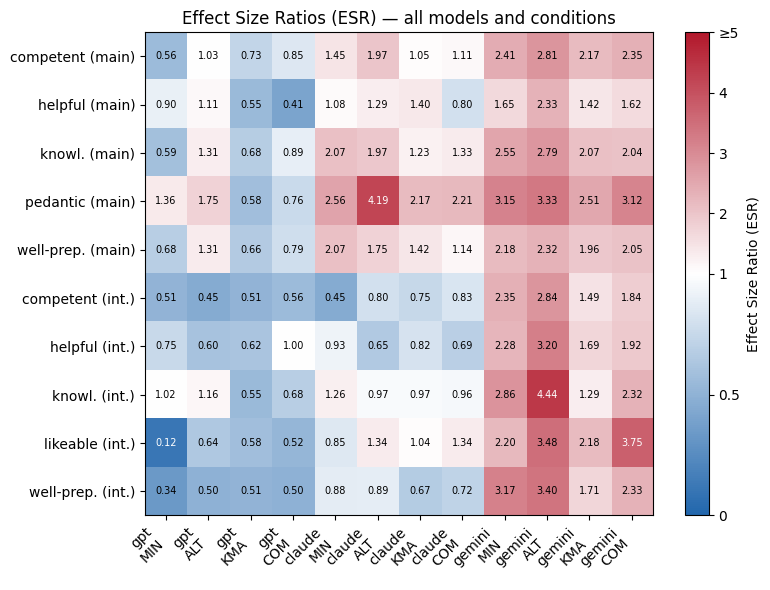

In [9]:
# ── ESR Heatmap (reproduces Figure 1) ────────────────────────────────────────
# Build a combined ESR dataframe across all models and conditions

esr_rows = []
for cond, llm_df in llm_dfs.items():
    for model in MODELS:
        mdf = llm_df[llm_df['model'] == model]
        if len(mdf) == 0:
            continue
        main = compute_esr_main_all(human_df, mdf)
        inter = compute_esr_interaction_all(human_df, mdf)
        for attr, vals in main.items():
            esr_rows.append({'model': model, 'prompt': cond, 'attribute': attr,
                             'effect_type': 'main', 'esr': vals['esr_main']})
        for attr, vals in inter.items():
            esr_rows.append({'model': model, 'prompt': cond, 'attribute': attr,
                             'effect_type': 'interaction', 'esr': vals['esr_interaction']})

esr_df_all = pd.DataFrame(esr_rows)

plot_esr_heatmap(
    esr_df_all,
    esr_col='esr',
    title='Effect Size Ratios (ESR) — all models and conditions',
    drop_non_significant=True,
    significant_main_attrs=SIGNIFICANT_MAIN_ATTRS,
    significant_interaction_attrs=SIGNIFICANT_INTERACTION_ATTRS,
    model_order=MODELS,
    prompt_order=CONDITIONS,
)

**Interpretation:** White cells indicate perfect calibration (ESR = 1). Red = exaggeration; blue = attenuation. Key observations:

- **GPT** is mostly blue or near-white — it tends to attenuate or closely match human effect sizes
- **Claude** shows strong red for main effects (exaggeration) but more moderate interaction effects
- **Gemini** shows pervasive deep red — systematic and severe exaggeration across nearly all effects
- The **KMA column** consistently shifts cells toward white for Claude and Gemini, showing the benefit of knowledge-and-motives-aware prompting

---

## 7. Run Your Own Experiment *(optional)*

This section lets you run a condensed version of the experiment yourself — one model, one prompting condition, one scenario.

**Requirements:** API keys for the model you want to query. Create a `.env` file in the repo root based on `.env.example`, or set the keys as environment variables.

If no API keys are found, this section will skip gracefully — you can still explore all results above using the pre-collected data.

In [10]:
# ── Check for API keys ────────────────────────────────────────────────────────
from dotenv import load_dotenv
load_dotenv()

import os
KEYS = {
    'gpt':    os.getenv('OPENAI_API_KEY'),
    'claude': os.getenv('ANTHROPIC_API_KEY'),
    'gemini': os.getenv('GOOGLE_API_KEY'),
}

available_models = [m for m, k in KEYS.items() if k]
if available_models:
    print(f'API keys found for: {", ".join(available_models)}')
    print('You can run the experiment cells below.')
else:
    print('No API keys found — skipping experiment section.')
    print('To run, add your keys to a .env file (see .env.example).')

KEYS_AVAILABLE = bool(available_models)

API keys found for: gpt, claude, gemini
You can run the experiment cells below.


In [11]:
# ── Interactive configuration ─────────────────────────────────────────────────
if KEYS_AVAILABLE:
    import ipywidgets as widgets
    from IPython.display import display as ipy_display

    model_selector = widgets.Dropdown(
        options=available_models,
        description='Model:',
        style={'description_width': 'initial'}
    )
    condition_selector = widgets.Dropdown(
        options=['MIN', 'ALT', 'KMA', 'COM'],
        description='Prompting condition:',
        style={'description_width': 'initial'}
    )
    scenario_selector = widgets.Dropdown(
        options=['bicycle', 'house', 'cinema', 'conference', 'office', 'pasta'],
        description='Scenario:',
        style={'description_width': 'initial'}
    )
    n_runs_slider = widgets.IntSlider(
        value=3, min=1, max=10, step=1,
        description='Runs per condition:',
        style={'description_width': 'initial'}
    )

    ipy_display(widgets.VBox([
        widgets.Label('Configure your experiment:'),
        model_selector, condition_selector, scenario_selector, n_runs_slider
    ]))
else:
    print('(Skipped — no API keys available)')

In [12]:
# ── Run experiment ────────────────────────────────────────────────────────────
if KEYS_AVAILABLE:
    from src.collection.models import MODEL_CALLERS
    from src.parsing import parse_likert_response
    from src.config import SCENARIOS, ATTRIBUTES, CONTEXTS, UTTERANCES
    from prompts.build_prompts import (
        build_minimal_prompt, build_alt_prompt,
        build_kma_prompt, build_combined_prompt
    )
    import time

    PROMPT_BUILDERS = {
        'MIN': build_minimal_prompt,
        'ALT': build_alt_prompt,
        'KMA': build_kma_prompt,
        'COM': build_combined_prompt,
    }

    selected_model     = model_selector.value
    selected_condition = condition_selector.value
    selected_scenario  = scenario_selector.value
    n_runs             = n_runs_slider.value

    build_prompt = PROMPT_BUILDERS[selected_condition]
    scenario_items = SCENARIOS[selected_scenario]
    caller = MODEL_CALLERS[selected_model]

    print(f'Running: model={selected_model} | condition={selected_condition} | '
          f'scenario={selected_scenario} | runs={n_runs}\n')

    run_results = []
    for context in CONTEXTS:
        for utterance in UTTERANCES:
            for attribute in ATTRIBUTES:
                prompt = build_prompt(
                    scenario_items=scenario_items,
                    context=context,
                    utterance=utterance,
                    attribute=attribute
                )
                ratings = []
                for _ in range(n_runs):
                    raw = caller(prompt)
                    likert, valid = parse_likert_response(raw)
                    if valid:
                        ratings.append(likert)
                    time.sleep(0.2)

                mean_rating = np.mean(ratings) if ratings else None
                run_results.append({
                    'context': context, 'utterance': utterance,
                    'attribute': attribute, 'mean_rating': mean_rating,
                    'n_valid': len(ratings)
                })
                print(f'  {context:5s} | {utterance:8s} | {attribute:15s} → {mean_rating:.2f} (n={len(ratings)})')

    run_df = pd.DataFrame(run_results)
    print('\nDone.')
else:
    print('(Skipped — no API keys available)')

Running: model=gpt | condition=MIN | scenario=bicycle | runs=3

  low   | precise  | competent       → 6.00 (n=3)
  low   | precise  | likeable        → 6.00 (n=3)
  low   | precise  | pedantic        → 1.33 (n=3)
  low   | precise  | helpful         → 6.33 (n=3)
  low   | precise  | knowledgeable   → 5.67 (n=3)
  low   | precise  | well-prepared   → 6.00 (n=3)
  low   | approx   | competent       → 6.00 (n=3)
  low   | approx   | likeable        → 6.00 (n=3)
  low   | approx   | pedantic        → 1.00 (n=3)
  low   | approx   | helpful         → 6.67 (n=3)
  low   | approx   | knowledgeable   → 5.67 (n=3)
  low   | approx   | well-prepared   → 6.33 (n=3)
  high  | precise  | competent       → 6.00 (n=3)
  high  | precise  | likeable        → 6.00 (n=3)
  high  | precise  | pedantic        → 5.00 (n=3)
  high  | precise  | helpful         → 7.00 (n=3)
  high  | precise  | knowledgeable   → 6.33 (n=3)
  high  | precise  | well-prepared   → 6.33 (n=3)
  high  | approx   | competent      

In [13]:
# ── Compare your run to human benchmark ──────────────────────────────────────
if KEYS_AVAILABLE and 'run_df' in dir():
    human_scenario = (
        human_df[human_df['scenario'] == selected_scenario]
        .groupby(['context', 'utterance', 'attribute'])['rating']
        .mean().reset_index().rename(columns={'rating': 'human_mean'})
    )

    comparison = pd.merge(
        human_scenario,
        run_df.rename(columns={'mean_rating': 'model_mean'}),
        on=['context', 'utterance', 'attribute']
    )
    comparison['deviation'] = (comparison['model_mean'] - comparison['human_mean']).round(2)

    print(f'Human vs. {selected_model.upper()} ({selected_condition}) — scenario: {selected_scenario}\n')
    display(comparison[['context','utterance','attribute','human_mean','model_mean','deviation']].round(2))
else:
    print('(Skipped — no experiment was run)')

Human vs. GPT (MIN) — scenario: bicycle



,context,utterance,attribute,human_mean,model_mean,deviation
0,high,approx,competent,5.150,6.000,0.850
1,high,approx,helpful,5.080,6.670,1.590
2,high,approx,knowledgeable,5.000,5.000,0.000
3,high,approx,likeable,4.920,6.000,1.080
4,high,approx,pedantic,4.080,2.330,-1.740
5,high,approx,well-prepared,5.150,5.330,0.180
6,high,precise,competent,6.310,6.000,-0.310
7,high,precise,helpful,6.250,7.000,0.750
8,high,precise,knowledgeable,5.750,6.330,0.580
9,high,precise,likeable,4.880,6.000,1.120


---

## 8. Citation

If you use this code or the ESR/CDS metrics, please cite:

```bibtex
@inproceedings{muehlenbernd2026social,
  title     = {Social Meaning in Large Language Models: Structure, Magnitude, and Pragmatic Prompting},
  author    = {Mühlenbernd, Roland},
  booktitle = {Proceedings of the Workshop on Cognitive Modeling and Computational Linguistics (CMCL 2026)},
  year      = {2026}
}
```

For the human benchmark data:

```bibtex
@inproceedings{solt2025social,
  title     = {Social meaning and pragmatic reasoning: The case of (im)precision},
  author    = {Solt, Stephanie and Mühlenbernd, Roland and Burbelko, Mariya},
  booktitle = {Proceedings of the Experiments in Linguistic Meaning (ELM 3)},
  pages     = {371--382},
  year      = {2025},
  doi       = {10.17605/OSF.IO/M4RHN}
}
```